In [4]:
#TASK:1

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# load the three dataset
sales = pd.read_csv("sales.csv")
customers = pd.read_csv("customers.csv")
products = pd.read_csv("products.csv")

# Quick inspections
print("sales:")
display(sales.head())

print("customers:")
display(customers.head())

print("products:")
display(products.head())

#checked columns and shared keys
print("\nsales columns:", sales.columns.tolist())
print("\ncustomers columns:" , customers.columns.tolist())
print("\nproducts columns:" , products.columns.tolist())

# build amster table using left join 

full = (
    sales
    .merge(customers, on="customer_id", how ="left")
    .merge(products, on="product_id", how="left")
)

#calculate revenue
full["revenue"] = full["quantity"] * full["unit_price"]

print("\nMaster table:")
display(full.head())

# compare diffrent join types
customer_left = sales.merge(customers, on="customer_id", how="left")
customer_inner = sales.merge(customers, on="customer_id", how="inner")
customer_outer = sales.merge(customers, on="customer_id", how="outer")

print("\nCustomer join row counts:")
print("Sales rows:", len(sales))
print("LEFT join:", len(customer_left))
print("INNER join:", len(customer_inner))
print("OUTER join:", len(customer_outer))

# Find sales with unknown customers
failed_customer_lookup = customer_left["region"].isna().sum()

print("\nSales with unknown customer:", failed_customer_lookup)

# Find customers who never ordered
ordered_customer_ids = set(sales["customer_id"].dropna())
all_customer_ids = set(customers["customer_id"].dropna())

never_ordered = all_customer_ids - ordered_customer_ids

print("Customers who never ordered:", len(never_ordered))

# Show unmatched customers
if len(never_ordered) > 0:
    never_ordered_df = customers[
        customers["customer_id"].isin(never_ordered)
    ]
    display(never_ordered_df)




sales:


,order_id,date,customer_id,product_id,quantity
0,O00001,31-10-2024,C999,P019,2
1,O00002,14-03-2024,C999,P014,1
2,O00003,21-10-2024,C999,P004,1
3,O00004,03-01-2024,C999,P003,3
4,O00005,18-10-2024,C999,P018,4


customers:


,customer_id,customer_name,region,signup_year
0,C001,Customer_1,North,2024
1,C002,Customer_2,West,2021
2,C003,Customer_3,East,2022
3,C004,Customer_4,South,2022
4,C005,Customer_5,South,2022


products:


,product_id,product_name,category,unit_price
0,P001,Laptop,Electronics,800
1,P002,Mouse,Electronics,25
2,P003,Keyboard,Electronics,45
3,P004,Monitor,Electronics,250
4,P005,Webcam,Electronics,60



sales columns: ['order_id', 'date', 'customer_id', 'product_id', 'quantity']

customers columns: ['customer_id', 'customer_name', 'region', 'signup_year']

products columns: ['product_id', 'product_name', 'category', 'unit_price']

Master table:


,order_id,date,customer_id,product_id,quantity,customer_name,region,signup_year,product_name,category,unit_price,revenue
0,O00001,31-10-2024,C999,P019,2,NaN,NaN,NaN,Microphone,Electronics,110,220
1,O00002,14-03-2024,C999,P014,1,NaN,NaN,NaN,Water Bottle,Accessories,20,20
2,O00003,21-10-2024,C999,P004,1,NaN,NaN,NaN,Monitor,Electronics,250,250
3,O00004,03-01-2024,C999,P003,3,NaN,NaN,NaN,Keyboard,Electronics,45,135
4,O00005,18-10-2024,C999,P018,4,NaN,NaN,NaN,Speaker,Electronics,90,360



Customer join row counts:
Sales rows: 1000
LEFT join: 1000
INNER join: 995
OUTER join: 1002

Sales with unknown customer: 5
Customers who never ordered: 2


,customer_id,customer_name,region,signup_year
50,C051,Customer_51,North,2024
51,C052,Customer_52,South,2024


## Task 01 — Master Table

### What was done
- Loaded `sales.csv`, `customers.csv`, and `products.csv`.
- `customer_id` connects sales with customers.
- `product_id` connects sales with products.
- Used a **LEFT JOIN** so every sale remains in the master table.
- Added `revenue = quantity × unit_price`.
- Compared LEFT, INNER and OUTER joins.
- Identified unknown customers and customers who never ordered.

### Lookup Questions

**1. What is the danger of using an INNER JOIN without checking?**  
An INNER JOIN removes unmatched rows. Sales with unknown customers would disappear, causing the analysis to undercount sales or revenue.

**2. How can failed customer lookups be found?**  
After a LEFT JOIN, check rows where `region` is `NaN`.

**3. When is an OUTER JOIN useful?**  
An OUTER JOIN is useful when we want to see both matched and unmatched records from both tables.

**4. Which join type was used for the customer merge and why?**  
A LEFT JOIN was used because every sale should remain in the master table, even when customer information is missing.

In [5]:
# Make sure date is in datetime format
full["date"] = pd.to_datetime(full["date"])

# Create month for monthly analysis
full["month"] = full["date"].dt.to_period("M").astype(str)

# ---------------------------------------------------------
# 1. Total revenue per region
# ---------------------------------------------------------

region_revenue = (
    full.groupby("region")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

print("Total revenue by region:")
display(region_revenue)

print("\nRanked regions:")
region_rank = region_revenue.rank(method="dense", ascending=False).astype(int)
display(
    pd.DataFrame({
        "total_revenue": region_revenue,
        "rank": region_rank
    })
)

# 2. Total revenue per product category
# ---------------------------------------------------------

category_revenue = (
    full.groupby("category")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

print("\nTotal revenue by category:")
display(category_revenue)

# ---------------------------------------------------------
# 3. Multiple aggregations per category
# ---------------------------------------------------------

category_summary = (
    full.groupby("category")
    .agg(
        total_revenue=("revenue", "sum"),
        average_order_revenue=("revenue", "mean"),
        number_of_orders=("order_id", "count")
    )
    .sort_values("total_revenue", ascending=False)
)

print("\nCategory summary:")
display(category_summary)

# ---------------------------------------------------------
# 4. Revenue by region and month
# ---------------------------------------------------------

region_month = (
    full.groupby(["region", "month"])["revenue"]
    .sum()
    .reset_index()
)

print("\nRevenue by region and month:")
display(region_month.head(20))

# ---------------------------------------------------------
# 5. Best and worst month for one region
# ---------------------------------------------------------

selected_region = region_revenue.index[0]

selected_region_month = (
    region_month[
        region_month["region"] == selected_region
    ]
    .sort_values("revenue", ascending=False)
)

best_month = selected_region_month.iloc[0]
worst_month = selected_region_month.iloc[-1]

print(f"\nSelected region: {selected_region}")
print(
    f"Best month: {best_month['month']} "
    f"with revenue {best_month['revenue']:.2f}"
)
print(
    f"Worst month: {worst_month['month']} "
    f"with revenue {worst_month['revenue']:.2f}"
)

Total revenue by region:


C:\Users\neel2\AppData\Local\Temp\ipykernel_20936\1759174568.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  full["date"] = pd.to_datetime(full["date"])


region
East     121636
West     117271
North     83444
South     81814
Name: revenue, dtype: int64


Ranked regions:


,total_revenue,rank
region,,
East,121636,1
West,117271,2
North,83444,3
South,81814,4


...


Category summary:


,total_revenue,average_order_revenue,number_of_orders
category,,,
Electronics,285690,466.813725,612
Office,104000,641.975309,162
Accessories,12081,92.930769,130
Stationery,3379,35.197917,96



Revenue by region and month:


,region,month,revenue
0,East,2024-01,11506
1,East,2024-02,11110
2,East,2024-03,13911
3,East,2024-04,10275
4,East,2024-05,5976
5,East,2024-06,6378
6,East,2024-07,9568
7,East,2024-08,12035
8,East,2024-09,12640
9,East,2024-10,8635



Selected region: East
Best month: 2024-12 with revenue 14573.00
Worst month: 2024-11 with revenue 5029.00


## Task 02 — GroupBy Revenue Analysis

### What was done
- Calculated total revenue for each region.
- Ranked regions by revenue.
- Calculated total revenue for each product category.
- Used `.agg()` to calculate:
  - total revenue
  - average order revenue
  - number of orders
- Grouped by both `region` and `month`.
- Found the best and worst month for the selected region.

### Lookup Questions

**1. What is the difference between total revenue and average order value?**  
Total revenue shows the complete money generated. Average order revenue shows the average revenue generated per order.

**2. Can a category have high total revenue but low average order revenue?**  
Yes. A category can have many orders with relatively small values, producing high total revenue but low average revenue per order.

**3. Why is two-column grouping useful?**  
Grouping by two columns allows us to analyze a combination, such as revenue for each region in each month.

**4. Which category drives the business?**  
The category with the highest `total_revenue` in `category_summary` is the highest-revenue category.

In [6]:
# ---------------------------------------------------------
# 1. Region x Category revenue pivot
# ---------------------------------------------------------

region_category_pivot = full.pivot_table(
    values="revenue",
    index="region",
    columns="category",
    aggfunc="sum",
    fill_value=0,
    margins=True
)

print("Revenue by Region and Category:")
display(region_category_pivot)

# ---------------------------------------------------------
# 2. Region x Month revenue pivot
# ---------------------------------------------------------

region_month_pivot = full.pivot_table(
    values="revenue",
    index="region",
    columns="month",
    aggfunc="sum",
    fill_value=0,
    margins=True
)

print("\nRevenue by Region and Month:")
display(region_month_pivot)

# ---------------------------------------------------------
# 3. Crosstab: number of orders
# ---------------------------------------------------------

order_crosstab = pd.crosstab(
    full["region"],
    full["category"],
    margins=True
)

print("\nNumber of Orders by Region and Category:")
display(order_crosstab)

# ---------------------------------------------------------
# 4. Find highest revenue region-month combination
# ---------------------------------------------------------

region_month_values = (
    full.groupby(["region", "month"])["revenue"]
    .sum()
)

highest_region_month = region_month_values.idxmax()
highest_revenue = region_month_values.max()

print("\nHighest revenue region-month:")
print("Region:", highest_region_month[0])
print("Month:", highest_region_month[1])
print("Revenue:", round(highest_revenue, 2))

Revenue by Region and Category:


category,Accessories,Electronics,Office,Stationery,All
region,,,,,
East,3379,86260,31020,977,121636
North,2231,56815,23420,978,83444
South,3341,55530,22440,503,81814
West,3110,86120,27120,921,117271
All,12061,284725,104000,3379,404165



Revenue by Region and Month:


month,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12,All
region,,,,,,,,,,,,,
East,11506,11110,13911,10275,5976,6378,9568,12035,12640,8635,5029,14573,121636
North,2975,12119,7269,8534,11601,6915,5573,3604,4852,6562,5831,7609,83444
South,6114,12525,10415,3930,6320,3685,5078,6931,7848,6331,6404,6233,81814
West,11831,12241,6993,5963,3394,14742,14303,8677,4520,8262,16039,10306,117271
All,32426,47995,38588,28702,27291,31720,34522,31247,29860,29790,33303,38721,404165



Number of Orders by Region and Category:


category,Accessories,Electronics,Office,Stationery,All
region,,,,,
East,33,156,45,26,260
North,26,143,38,22,229
South,32,114,36,19,201
West,38,195,43,29,305
All,129,608,162,96,995



Highest revenue region-month:
Region: West
Month: 2024-11
Revenue: 16039


## Task 03 — Pivot Table and Crosstab

### What was done
- Created a region × category revenue pivot.
- Created a region × month revenue pivot.
- Used `fill_value=0` for combinations with no revenue.
- Used `margins=True` to add row and column totals.
- Created a crosstab showing the number of orders.
- Found the region-month combination with the highest revenue.

### Lookup Questions

**1. What is the difference between `pivot_table()` and `crosstab()`?**  
`pivot_table()` is mainly used to summarize numerical values such as revenue. `crosstab()` is mainly used to count combinations of categorical values.

**2. Why use `fill_value=0`?**  
It replaces missing combinations with zero, meaning there was no recorded value for that combination.

**3. Could `groupby()` create the same information?**  
Yes. `groupby()` can calculate the same summary, but `pivot_table()` displays the result in a convenient rows × columns grid.

**4. What does `margins=True` do?**  
It adds totals for rows and columns.

Date features:


,date,month_number,month_name,day_name,quarter
0,2024-10-31,10,October,Thursday,4
1,2024-03-14,3,March,Thursday,1
2,2024-10-21,10,October,Monday,4
3,2024-01-03,1,January,Wednesday,1
4,2024-10-18,10,October,Friday,4



Revenue by day of week:


day_name
Monday       51266
Tuesday      61293
Wednesday    43207
Thursday     67003
Friday       56667
Saturday     50325
Sunday       75389
Name: revenue, dtype: int64

Busiest day: Sunday with revenue 75389.00

Monthly revenue:


date
2024-01-31    32561
2024-02-29    47995
2024-03-31    38608
2024-04-30    28702
2024-05-31    27291
2024-06-30    31720
2024-07-31    34522
2024-08-31    31247
2024-09-30    29860
2024-10-31    30620
2024-11-30    33303
2024-12-31    38721
Freq: ME, Name: revenue, dtype: int64

Peak month: 2024-02 with revenue 47995.00


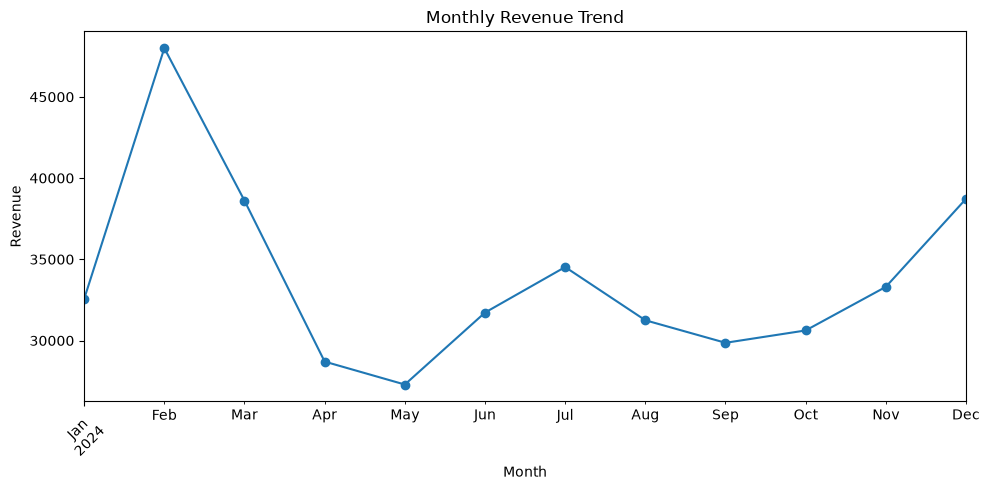


Weekly revenue:


date
2024-01-07    10707
2024-01-14    13783
2024-01-21     4246
2024-01-28     2010
2024-02-04    16042
2024-02-11     7075
2024-02-18     8341
2024-02-25    11364
2024-03-03     9165
2024-03-10    10069
Freq: W-SUN, Name: revenue, dtype: int64

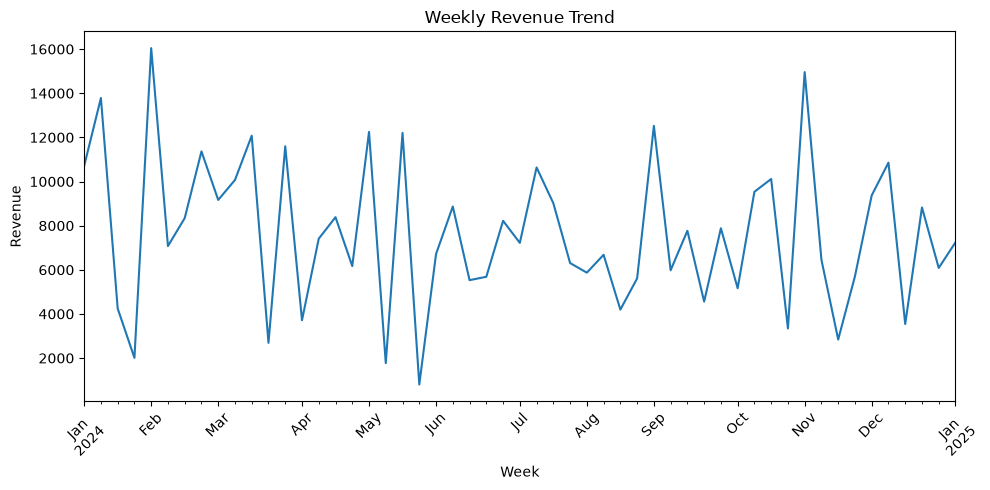


Comparison:
Monthly data contains fewer points and usually shows the broader trend.
Weekly data contains more points and usually shows more short-term variation.


In [8]:
# Make sure date is datetime
full["date"] = pd.to_datetime(full["date"])

# ---------------------------------------------------------
# 1. Extract date features
# ---------------------------------------------------------

full["month_number"] = full["date"].dt.month
full["month_name"] = full["date"].dt.month_name()
full["day_name"] = full["date"].dt.day_name()
full["quarter"] = full["date"].dt.quarter

print("Date features:")
display(
    full[
        [
            "date",
            "month_number",
            "month_name",
            "day_name",
            "quarter"
        ]
    ].head()
)

# ---------------------------------------------------------
# 2. Revenue by day of week
# ---------------------------------------------------------

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_revenue = (
    full.groupby("day_name")["revenue"]
    .sum()
    .reindex(weekday_order)
)

print("\nRevenue by day of week:")
display(weekday_revenue)

busiest_day = weekday_revenue.idxmax()
busiest_day_revenue = weekday_revenue.max()

print(
    f"Busiest day: {busiest_day} "
    f"with revenue {busiest_day_revenue:.2f}"
)

# ---------------------------------------------------------
# 3. Monthly resampling
# ---------------------------------------------------------

monthly_revenue = (
    full.set_index("date")["revenue"]
    .resample("ME")
    .sum()
)

print("\nMonthly revenue:")
display(monthly_revenue)

peak_month = monthly_revenue.idxmax()
peak_month_revenue = monthly_revenue.max()

print(
    f"Peak month: {peak_month.strftime('%Y-%m')} "
    f"with revenue {peak_month_revenue:.2f}"
)

# Monthly plot
monthly_revenue.plot(
    kind="line",
    marker="o",
    figsize=(10, 5),
    title="Monthly Revenue Trend"
)

plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 4. Weekly resampling
# ---------------------------------------------------------

weekly_revenue = (
    full.set_index("date")["revenue"]
    .resample("W")
    .sum()
)

print("\nWeekly revenue:")
display(weekly_revenue.head(10))

# Weekly plot
weekly_revenue.plot(
    kind="line",
    figsize=(10, 5),
    title="Weekly Revenue Trend"
)

plt.xlabel("Week")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Basic comparison
print("\nComparison:")
print("Monthly data contains fewer points and usually shows the broader trend.")
print("Weekly data contains more points and usually shows more short-term variation.")

## Task 04 — Date Analysis

### What was done
- Converted `date` to datetime using `pd.to_datetime()`.
- Extracted:
  - month
  - month name
  - day name
  - quarter
- Calculated revenue for Monday–Sunday in natural order.
- Identified the busiest day.
- Resampled revenue by month.
- Created a monthly revenue trend plot.
- Resampled revenue by week and compared it with monthly data.

### Lookup Questions

**1. Why must the date be parsed before extracting day or month?**  
Pandas needs the column to be a datetime type before `.dt` operations such as `.dt.month` or `.dt.day_name()` can be used.

**2. Why use resampling instead of simply grouping by month?**  
Resampling works with the actual time index and preserves the chronological time-series structure. Grouping only by month number can mix January from different years.

**3. How can weekday patterns affect business decisions?**  
A business can use busy-day information for staffing, inventory planning and promotions.

**4. Which shows more short-term noise: weekly or monthly data?**  
Weekly data usually shows more short-term variation because it contains more frequent observations.

**5. What should be written about the time pattern?**  
Use the output to report the busiest day, peak month and whether revenue generally rises, falls or fluctuates over time.

In [9]:
# ---------------------------------------------------------
# 1. Find product names containing a letter/pattern
# ---------------------------------------------------------

products_with_a = products[
    products["product_name"].str.contains(
        "a",
        case=False,
        na=False
    )
]

print("Products containing the letter 'a':")
display(products_with_a)

# ---------------------------------------------------------
# 2. Uppercase category
# ---------------------------------------------------------

products["category_upper"] = (
    products["category"]
    .str.upper()
)

# ---------------------------------------------------------
# 3. Product and category lengths
# ---------------------------------------------------------

products["product_name_length"] = (
    products["product_name"]
    .str.len()
)

products["category_length"] = (
    products["category"]
    .str.len()
)

print("\nString-derived columns:")
display(
    products[
        [
            "product_name",
            "category",
            "category_upper",
            "product_name_length",
            "category_length"
        ]
    ].head()
)

# ---------------------------------------------------------
# 4. Customer IDs ending with a particular digit
# ---------------------------------------------------------

customer_ids = full["customer_id"].astype(str)

ending_digit = "5"

ending_digit_count = (
    customer_ids
    .str.endswith(ending_digit, na=False)
    .sum()
)

print(
    f"\nCustomer IDs ending with {ending_digit}:",
    ending_digit_count
)

# Customer IDs starting with a particular pattern
starting_pattern = "1"

starting_pattern_count = (
    customer_ids
    .str.startswith(starting_pattern, na=False)
    .sum()
)

print(
    f"Customer IDs starting with {starting_pattern}:",
    starting_pattern_count
)

# ---------------------------------------------------------
# 5. Clean inconsistent text
# ---------------------------------------------------------

products["category_clean"] = (
    products["category"]
    .str.strip()
    .str.title()
)

products["product_name_clean"] = (
    products["product_name"]
    .str.strip()
    .str.title()
)

print("\nCleaned text:")
display(
    products[
        [
            "product_name",
            "product_name_clean",
            "category",
            "category_clean"
        ]
    ].head(10)
)

# Show unique cleaned categories
print("\nCleaned categories:")
print(products["category_clean"].unique())

Products containing the letter 'a':


,product_id,product_name,category,unit_price
0,P001,Laptop,Electronics,800
2,P003,Keyboard,Electronics,45
4,P005,Webcam,Electronics,60
5,P006,Headphones,Electronics,120
7,P008,Desk Lamp,Office,40
8,P009,Chair,Office,180
9,P010,Standing Desk,Office,400
12,P013,Backpack,Accessories,55
13,P014,Water Bottle,Accessories,20
14,P015,Phone Stand,Accessories,18



String-derived columns:


,product_name,category,category_upper,product_name_length,category_length
0,Laptop,Electronics,ELECTRONICS,6,11
1,Mouse,Electronics,ELECTRONICS,5,11
2,Keyboard,Electronics,ELECTRONICS,8,11
3,Monitor,Electronics,ELECTRONICS,7,11
4,Webcam,Electronics,ELECTRONICS,6,11



Customer IDs ending with 5: 92
Customer IDs starting with 1: 0

Cleaned text:


,product_name,product_name_clean,category,category_clean
0,Laptop,Laptop,Electronics,Electronics
1,Mouse,Mouse,Electronics,Electronics
2,Keyboard,Keyboard,Electronics,Electronics
3,Monitor,Monitor,Electronics,Electronics
4,Webcam,Webcam,Electronics,Electronics
5,Headphones,Headphones,Electronics,Electronics
6,USB Hub,Usb Hub,Electronics,Electronics
7,Desk Lamp,Desk Lamp,Office,Office
8,Chair,Chair,Office,Office
9,Standing Desk,Standing Desk,Office,Office



Cleaned categories:
<StringArray>
['Electronics', 'Office', 'Stationery', 'Accessories']
Length: 4, dtype: str


## Task 05 — String Operations

### What was done
- Used `.str.contains()` to find product names containing a pattern.
- Converted categories to uppercase.
- Calculated product and category name lengths.
- Counted customer IDs based on starting and ending patterns.
- Removed extra spaces using `.str.strip()`.
- Standardized capitalization using `.str.title()`.

### Lookup Questions

**1. Why are vectorized `.str` operations better than loops?**  
They are designed to operate efficiently on an entire Pandas column and make the code shorter and easier to read.

**2. Why use `case=False` with `.str.contains()`?**  
It makes the search case-insensitive, so uppercase and lowercase versions are both matched.

**3. Why can text data become messy?**  
Text can come from different users, systems or files and may contain extra spaces, inconsistent capitalization, spelling differences or different formats.

**4. Why is text cleaning important?**  
Inconsistent text can cause the same category or product to be treated as different values during analysis.

**5. What does `.str.strip()` do?**  
It removes unnecessary spaces from the beginning and end of text.

**6. What does `.str.title()` do?**  
It converts text to title case, making capitalization more consistent.